# Composite chiral magnet benchmark

This example reproduces the benchmark problem introduced in

> V. Laliena, J. Campo, and Y. Kousaka. *Analytical and numerical study of the ground state of a composite chiral magnet.* Physical Review B, **109**:214424, 2024.

A one-dimensional composite consisting of a chiral slab sandwiched between two ferromagnetic slabs is relaxed to its ground state. Because the Dzyaloshinskii–Moriya interaction (DMI) is non-zero only inside the chiral region, the ground state is a Bloch helix in the centre that is matched to exponentially decaying profiles in the outer ferromagnetic regions. Laliena *et al.* provide a closed-form analytical solution that we use to validate the numerical simulation.

## Problem setup

The system is symmetric about $x=0$ and occupies $|x|\le L=150\,\mathrm{nm}$. The chiral region covers $|x|\le L_0=100\,\mathrm{nm}$ and uses exchange $A$, bulk DMI constant $D$ and easy-plane anisotropy $K_c = -(h_c-1)\,D^2/A$ with reduced field $h_c=6$. The ferromagnetic slabs use exchange $\rho\,A$ (with $\rho=3$), $D=0$ and easy-axis anisotropy $K_u = \rho\,D^2/(4A)$ with easy axis along $\hat{\mathbf y}$.

The ground state is the Bloch helix $\mathbf m = (0,\cos\varphi,\sin\varphi)$ where the phase $\varphi$ satisfies

$$\varphi(x) = p\,q_0\,x \qquad \text{for } |x|\le L_0,$$

with $q_0 = D/(2A)$ and a pitch parameter $p$ that is fixed by matching the flux $2A\varphi' - D$ across the chiral–ferro interface at $x=\pm L_0$. Outside the chiral region the phase obeys the pendulum equation $\varphi'' = q_u^2\sin\varphi\cos\varphi$ with $q_u = q_0$.

## Simulation
### Import libraries
We import NumPy, SciPy and NeuralMag and set the default precision to double to guarantee convergence.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

import neuralmag as nm

nm.config.dtype = "float64"

2026-04-07 18:17:03 NeuralMag:INFO [NeuralMag] Version 0.9.3


2026-04-07 18:17:04 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.


2026-04-07 18:17:04 NeuralMag:INFO [NeuralMag] Set default dtype to 'float64'.


### Material parameters and geometry

All material constants are taken from the Laliena benchmark. The saturation magnetisation is $M_s = 10^6\,\mathrm{A/m}$, the exchange constant in the chiral region is $A = 10^{-11}\,\mathrm{J/m}$, and the bulk DMI constant is $D = 4\,\mathrm{mJ/m^2}$. The exchange ratio between ferro and chiral region is $\rho=3$ and the reduced anisotropy field is $h_c=6$. The total length is $2L = 300\,\mathrm{nm}$ discretised with cell size $\Delta x = 0.5\,\mathrm{nm}$ ($N=600$ cells).

In [2]:
# Physical parameters
A = 1e-11  # Exchange constant [J/m]
D = 4e-3  # Bulk DMI constant [J/m²]
rho = 3.0  # Exchange ratio ferro/chiral
hc = 6.0  # Reduced anisotropy field
Ms = 1e6  # Saturation magnetization [A/m]
q0 = D / (2 * A)
qu = q0
Kc = -(hc - 1) * D**2 / A  # Easy-plane anisotropy (chiral)
Ku = rho * D**2 / (4 * A)  # Easy-axis anisotropy (ferro)

# Geometry
L0 = 100e-9  # Half-width of chiral region [m]
L = 150e-9  # Half-width of total system [m]
dx = 0.5e-9  # Cell size [m]
N = round(2 * L / dx)

### Analytical solution

The matching condition at $x=\pm L_0$ determines the pitch parameter $p$ as the root of

$$f(p) = p - 1 + \frac{\rho\,q_u}{q_0}\sin(p\,q_0\,L_0) = 0$$

that lies closest to unity. We bracket and refine it with Brent's method. The phase in the ferromagnetic slabs is then obtained by integrating the pendulum equation with initial conditions $\varphi(L_0)=p\,q_0\,L_0$ and $\varphi'(L_0)=(p-1)\,q_0/\rho$.

In [3]:
def f_trans(p):
    return p - 1 + (rho * qu / q0) * np.sin(p * q0 * L0)


p_min = max(1 - np.sqrt(hc), 1 - rho * qu / q0)
p_max = min(1 + np.sqrt(hc), 1 + rho * qu / q0)
p_scan = np.linspace(p_min + 1e-10, p_max - 1e-10, 10000)
f_scan = f_trans(p_scan)
p_roots = []
for i in range(len(f_scan) - 1):
    if f_scan[i] * f_scan[i + 1] < 0:
        p_roots.append(brentq(f_trans, p_scan[i], p_scan[i + 1]))
p_val = np.array(p_roots)[np.argmin(np.abs(np.array(p_roots) - 1))]
print(f"pitch parameter p = {p_val:.6f}")

pitch parameter p = 0.943421


In [4]:
def analytical_profile(x, p):
    phi = np.zeros_like(x)
    # chiral region: linear phase
    mc = np.abs(x) <= L0
    phi[mc] = p * q0 * x[mc]
    # right ferro region: integrate pendulum equation
    mr = x > L0
    if np.any(mr):
        xr = np.clip(x[mr], L0, L)
        sol = solve_ivp(
            lambda t, y: [y[1], qu**2 * np.sin(y[0]) * np.cos(y[0])],
            [L0, L],
            [p * q0 * L0, (p - 1) * q0 / rho],
            t_eval=xr,
            rtol=1e-12,
            atol=1e-14,
        )
        phi[mr] = sol.y[0]
    # left ferro region: use symmetry
    ml = x < -L0
    if np.any(ml):
        xl = np.clip(-x[ml][::-1], L0, L)
        sol = solve_ivp(
            lambda t, y: [y[1], qu**2 * np.sin(y[0]) * np.cos(y[0])],
            [L0, L],
            [p * q0 * L0, (p - 1) * q0 / rho],
            t_eval=xl,
            rtol=1e-12,
            atol=1e-14,
        )
        phi[ml] = -sol.y[0][::-1]
    return phi

### Create mesh and state

We use a 1D nodal mesh with $N=600$ cells centred at the origin. The NeuralMag `State` holds all field quantities that live on this mesh.

In [ ]:
mesh = nm.Mesh((N,), (dx, dx, dx), origin=(-L, 0, 0))
state = nm.State(mesh)

# cell-centre and node coordinates along x (x_c as backend tensor so the
# conditions fed to state.add_domain are valid for both jax and torch)
x_c = state.coordinates()[0]
x_n = -L + np.arange(N + 1) * dx

### Material domains

The two regions (chiral and ferromagnetic) are introduced via domain labels, and the material parameters are assigned per domain using `fill_by_domain`. Domain `0` (the background) has zero material, domain `1` is the chiral slab and domain `2` is the ferromagnetic slab. The easy-axis direction of the anisotropy is $\hat{\mathbf x}$ (easy-plane $y$-$z$) in the chiral region and $\hat{\mathbf y}$ in the ferro region.

In [6]:
state.add_domain(1, abs(x_c) <= L0)
state.add_domain(2, abs(x_c) > L0)

state.material.Ms = nm.CellFunction(state).fill_by_domain([0.0, Ms, Ms])
state.material.A = nm.CellFunction(state).fill_by_domain([0.0, A, rho * A])
state.material.Db = nm.CellFunction(state).fill_by_domain([0.0, D, 0.0])
state.material.Ku = nm.CellFunction(state).fill_by_domain([0.0, Kc, Ku])
state.material.Ku_axis = nm.VectorCellFunction(state).fill_by_domain(
    [[0, 0, 0], [1, 0, 0], [0, 1, 0]]
)
state.material.alpha = 1.0

### Initial magnetisation

We seed the simulation with the analytical helix profile. The phase is evaluated at cell centres, the resulting magnetisation is averaged onto the nodal mesh and renormalised. Starting from the analytical profile ensures that the LLG relaxation converges to the correct winding number.

In [7]:
phi_n = analytical_profile(x_n, p_val)
m_init = np.zeros((N + 1, 3))
m_init[:, 1] = np.cos(phi_n)
m_init[:, 2] = np.sin(phi_n)

state.m = nm.VectorFunction(state, tensor=state.tensor(m_init))

### Effective field and relaxation

The total effective field contains contributions from exchange, bulk DMI and uniaxial anisotropy. After registering each contribution with the state, we relax the system to an energetic minimum with the Landau–Lifshitz–Gilbert solver.

In [8]:
nm.ExchangeField().register(state, "exchange")
nm.BulkDMIField().register(state, "dmi")
nm.UniaxialAnisotropyField().register(state, "aniso")
nm.TotalField("exchange", "dmi", "aniso").register(state)

llg = nm.LLGSolver(state, rtol=1e-8, atol=1e-8)
llg.relax()

2026-04-07 18:17:05 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')


2026-04-07 18:17:05 NeuralMag:INFO [BulkDMIField] Register state methods (field: 'h_dmi', energy: 'E_dmi', energy density: 'e_dmi')


2026-04-07 18:17:05 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso', energy density: 'e_aniso')


2026-04-07 18:17:05 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')


2026-04-07 18:17:05 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function


2026-04-07 18:17:05 NeuralMag:INFO [LLGSolverJAX] Relaxation started, initial energy E = -4.98922e-20 J


2026-04-07 18:17:06 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 3.12772e+09) 1/s


2026-04-07 18:17:08 NeuralMag:INFO [LLGSolverJAX] Relaxation finished, final energy E = -4.98922e-20 J


## Comparison with the analytical solution

We interpolate the relaxed nodal magnetisation onto the cell centres and plot the $m_y$ and $m_z$ components against the analytical helix.

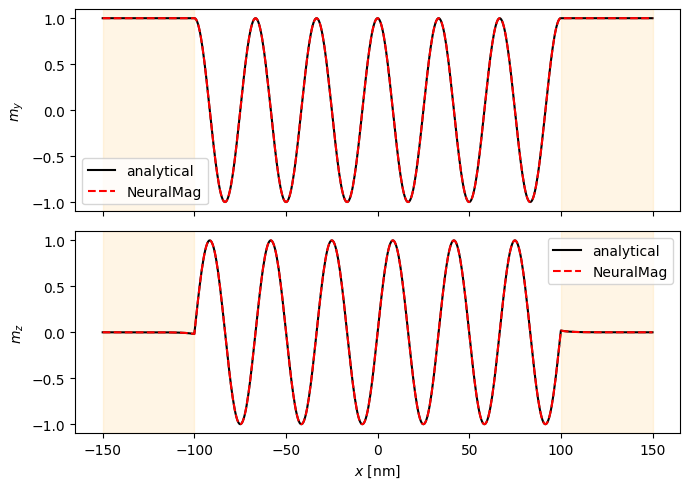

In [9]:
m_np = nm.config.backend.to_numpy(state.m.tensor)

phi_ref = analytical_profile(x_n, p_val)
my_ref = np.cos(phi_ref)
mz_ref = np.sin(phi_ref)

fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
axes[0].plot(x_n * 1e9, my_ref, "k-", label="analytical")
axes[0].plot(x_n * 1e9, m_np[:, 1], "r--", label="NeuralMag")
axes[0].axvspan(-L * 1e9, -L0 * 1e9, color="orange", alpha=0.1)
axes[0].axvspan(L0 * 1e9, L * 1e9, color="orange", alpha=0.1)
axes[0].set_ylabel(r"$m_y$")
axes[0].legend()

axes[1].plot(x_n * 1e9, mz_ref, "k-", label="analytical")
axes[1].plot(x_n * 1e9, m_np[:, 2], "r--", label="NeuralMag")
axes[1].axvspan(-L * 1e9, -L0 * 1e9, color="orange", alpha=0.1)
axes[1].axvspan(L0 * 1e9, L * 1e9, color="orange", alpha=0.1)
axes[1].set_xlabel(r"$x$ [nm]")
axes[1].set_ylabel(r"$m_z$")
axes[1].legend()

plt.tight_layout()
plt.show()

The shaded regions indicate the ferromagnetic slabs. The simulated magnetisation matches the analytical helix to within the discretisation error of the nodal finite-difference method. For a quantitative assessment one can compute the phase $\varphi$ from the components and plot its deviation from the analytical profile.

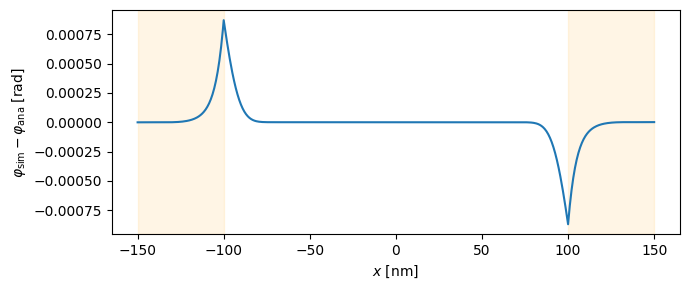

In [10]:
phi_sim = np.unwrap(np.arctan2(m_np[:, 2], m_np[:, 1]))
phi_ref_u = np.unwrap(phi_ref)
phi_sim += phi_ref_u[(N + 1) // 2] - phi_sim[(N + 1) // 2]

plt.figure(figsize=(7, 3))
plt.plot(x_n * 1e9, phi_sim - phi_ref_u)
plt.axvspan(-L * 1e9, -L0 * 1e9, color="orange", alpha=0.1)
plt.axvspan(L0 * 1e9, L * 1e9, color="orange", alpha=0.1)
plt.xlabel(r"$x$ [nm]")
plt.ylabel(r"$\varphi_{\mathrm{sim}} - \varphi_{\mathrm{ana}}$ [rad]")
plt.tight_layout()
plt.show()